# WCS 03 — Named Bright Object Sanity Check

**What this notebook tests:**
Does the WCS place Pollux, Castor, Alhena, etc. on the actual bright blobs?

**Critical method note:** We query SIMBAD by object *name* (`query_object`), NOT by coordinate nearest-match. Coordinate-nearest queries returned obscure catalog entries in previous tests. Jupiter is handled separately via `astropy.coordinates.get_body`.

**Target list:** Jupiter, Pollux, Castor, Alhena, Menkalinan, Kappa Gem, Gomeisa, Iota Gem, Wasat

In [1]:
import sys
from pathlib import Path
import warnings
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, get_body, EarthLocation
from astropy.time import Time
import astropy.units as u

OUT_DIR = ROOT / 'out' / 'wcs_diagnostics'
CACHE   = OUT_DIR / 'platesolve_result.pkl'

if not CACHE.exists():
    raise FileNotFoundError('Run wcs_01 first')
with open(CACHE, 'rb') as f:
    result = pickle.load(f)

fits_path = sorted((ROOT / 'data').glob('*.fit'))[0]
with afits.open(fits_path) as hdul:
    image  = hdul[0].data.astype(float)
    header = hdul[0].header.copy()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

print(f'Image: {fits_path.name}  {image.shape}')

Image: fuji6_asi178_100_15s.fit  (2080, 3096)


In [3]:
# --- Jupiter via ephemeris ---
# Use DATE-OBS from the FITS header if present; otherwise fall back to a
# manually specified time.  Adjust MANUAL_TIME to your observation epoch.
MANUAL_TIME = '2024-12-01T00:00:00'  # <-- set to your actual observation time if DATE-OBS is missing
obs_time_str = header.get('DATE-OBS') or header.get('DATE_OBS') or MANUAL_TIME
try:
    obs_time = Time(obs_time_str, format='isot', scale='utc')
except Exception:
    obs_time = Time(MANUAL_TIME, format='isot', scale='utc')
print(f'Observation time: {obs_time.isot}')

# EarthLocation: use header LAT/LON if present, else a nominal site
lat = float(header.get('SITELAT', header.get('LAT_OBS', 38.3)))
lon = float(header.get('SITELONG', header.get('LONG_OBS', -78.48)))
ele = float(header.get('SITEELEV', header.get('ALT_OBS', 50.0)))
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg, height=ele*u.m)
print(f'Observer location: lat={lat:.2f}° lon={lon:.2f}°')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    jup = get_body('jupiter', obs_time, location)
print(f'Jupiter at obs time: RA={jup.ra.deg:.4f}° Dec={jup.dec.deg:.4f}°')

Observation time: 2026-04-10T00:58:14.455
Observer location: lat=38.30° lon=-78.48°
Jupiter at obs time: RA=107.5235° Dec=22.8382°


In [4]:
# --- Query named stars directly by name ---
STAR_NAMES = ['Pollux', 'Castor', 'Alhena', 'Menkalinan',
              'kap Gem', 'Gomeisa', 'iot Gem', 'Wasat']

try:
    from astroquery.simbad import Simbad
    import warnings as _w

    def _col(tbl, *names):
        for n in names:
            if n in tbl.colnames:
                return n
        return None

    star_catalog = {}  # name -> SkyCoord
    for name in STAR_NAMES:
        with _w.catch_warnings():
            _w.simplefilter('ignore')
            tbl = Simbad.query_object(name)
        if tbl is None or len(tbl) == 0:
            print(f'  {name}: NOT FOUND in SIMBAD')
            continue
        ra_col  = _col(tbl, 'ra',  'RA')
        dec_col = _col(tbl, 'dec', 'DEC')
        try:
            coord = SkyCoord(ra=float(tbl[ra_col][0]),  dec=float(tbl[dec_col][0]),  unit=u.deg)
        except (ValueError, TypeError):
            coord = SkyCoord(ra=tbl[ra_col][0], dec=tbl[dec_col][0], unit=(u.hourangle, u.deg))
        star_catalog[name] = coord
        print(f'  {name:20s}: RA={coord.ra.deg:.4f}° Dec={coord.dec.deg:.4f}°')

except ImportError:
    print('astroquery not installed — pip install astroquery')
    star_catalog = {}

# Add Jupiter
star_catalog['Jupiter'] = SkyCoord(ra=jup.ra.deg*u.deg, dec=jup.dec.deg*u.deg)

  Pollux              : RA=116.3290° Dec=28.0262°
  Castor              : RA=113.6495° Dec=31.8883°
  Alhena              : RA=99.4280° Dec=16.3993°
  Menkalinan          : RA=89.8822° Dec=44.9474°
  kap Gem             : RA=116.1118° Dec=24.3980°
  Gomeisa             : RA=111.7877° Dec=8.2893°
  iot Gem             : RA=111.4316° Dec=27.7981°
  Wasat               : RA=110.0307° Dec=21.9823°


In [5]:
# Convert catalog RA/Dec to predicted pixel positions
predictions = {}
for name, coord in star_catalog.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        px, py = wcs.world_to_pixel_values(coord.ra.deg, coord.dec.deg)
    predictions[name] = {'ra': coord.ra.deg, 'dec': coord.dec.deg,
                         'pred_x': float(px), 'pred_y': float(py)}

# Find nearest detected centroid for each predicted position
def nearest_detected(pred_x, pred_y, det_x, det_y):
    dists = np.hypot(det_x - pred_x, det_y - pred_y)
    idx   = np.argmin(dists)
    return float(det_x[idx]), float(det_y[idx]), float(dists[idx])

if len(result.detected_x) > 0:
    for name, p in predictions.items():
        nx, ny, nd = nearest_detected(p['pred_x'], p['pred_y'],
                                      result.detected_x, result.detected_y)
        p['near_x'] = nx; p['near_y'] = ny; p['px_dist'] = nd
        # angular residual at this pixel position
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            det_ra, det_dec = wcs.pixel_to_world_values(nx, ny)
        cat = SkyCoord(ra=p['ra']*u.deg, dec=p['dec']*u.deg)
        det = SkyCoord(ra=det_ra*u.deg,  dec=det_dec*u.deg)
        p['sep_arcsec'] = float(cat.separation(det).arcsec)

In [6]:
from astropy.wcs import utils as wutils

print(f"{'Object':20s}  {'RA':>12}  {'Dec':>12}  {'pred_x':>8}  {'pred_y':>8}  "
      f"{'near_x':>8}  {'near_y':>8}  {'px_dist':>8}  {'sep\"':>8}  {'in_frame':>8}")
print('─' * 110)
h, w = image.shape
for name, p in predictions.items():
    in_frame = 0 <= p['pred_x'] < w and 0 <= p['pred_y'] < h
    nd  = p.get('px_dist', float('nan'))
    sep = p.get('sep_arcsec', float('nan'))
    nx  = p.get('near_x', float('nan'))
    ny  = p.get('near_y', float('nan'))
    print(f"{name:20s}  {p['ra']:>12.5f}  {p['dec']:>12.5f}  "
          f"{p['pred_x']:>8.1f}  {p['pred_y']:>8.1f}  "
          f"{nx:>8.1f}  {ny:>8.1f}  {nd:>8.1f}  {sep:>8.1f}  "
          f"{'YES' if in_frame else 'NO':>8}")

in_frame_preds = {n: p for n, p in predictions.items()
                 if 0 <= p['pred_x'] < w and 0 <= p['pred_y'] < h}
seps = [p['sep_arcsec'] for p in in_frame_preds.values() if not np.isnan(p.get('sep_arcsec', np.nan))]
if seps:
    print(f'\nIn-frame objects: {len(in_frame_preds)}  mean sep={np.mean(seps):.1f}"  max sep={np.max(seps):.1f}"')

Object                          RA           Dec    pred_x    pred_y    near_x    near_y   px_dist      sep"  in_frame
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
Pollux                   116.32896      28.02620    1467.2    1173.2    1471.1    1174.6       4.1     330.2       YES
Castor                   113.64947      31.88828    1519.8     979.1    1520.9     980.6       1.8     149.2       YES
Alhena                    99.42796      16.39928    2355.5    1443.7    2308.7    1433.6      47.9    3271.1       YES
Menkalinan                89.88218      44.94743    2114.3      26.4    2170.6      36.0      57.1    3995.1       YES
kap Gem                  116.11185      24.39800    1519.5    1326.6    1522.2    1328.4       3.3     264.6       YES
Gomeisa                  111.78767       8.28932    1937.5    2005.4    1915.4    1979.3      34.2    2346.1       YES
iot Gem                  111.43165      27.79808    1657

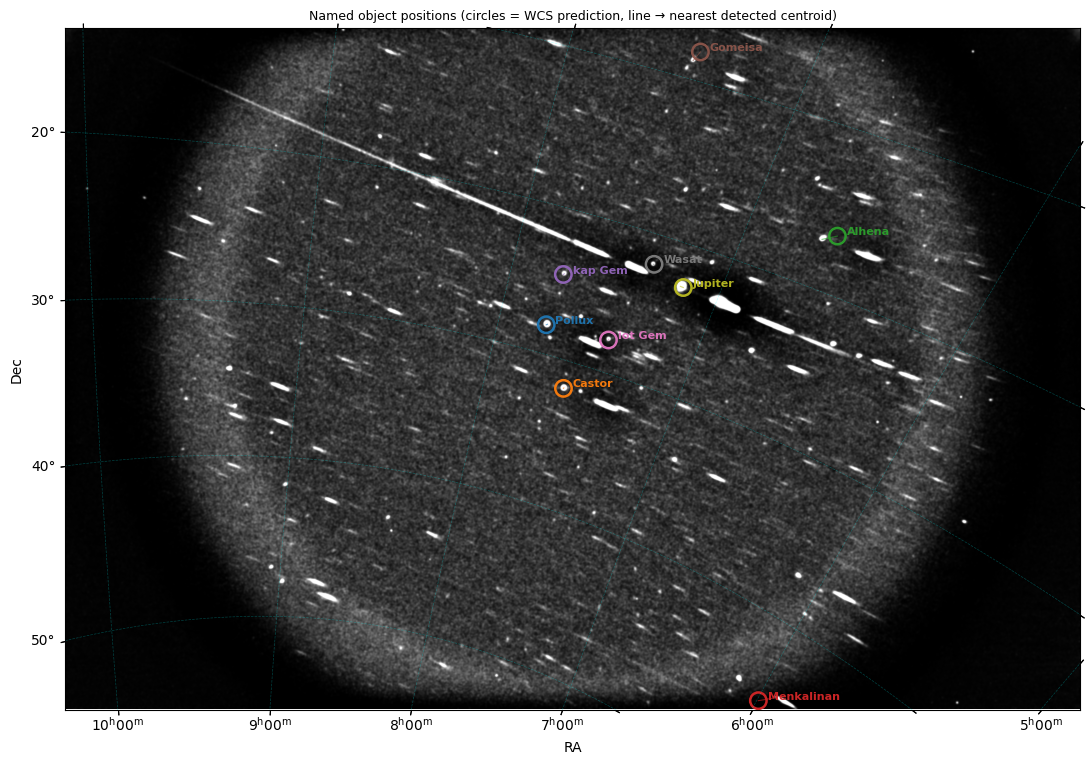

In [7]:
bg   = gaussian_filter(image.astype(np.float32), sigma=50.0)
proc = np.clip(image.astype(np.float32) - bg, 0.0, None)
proc = gaussian_filter(proc, sigma=2.5)
lo, hi = np.percentile(proc[np.isfinite(proc)], [0.5, 99.5])
disp = np.arcsinh(np.clip(proc, lo, hi))

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    fig, ax = plt.subplots(figsize=(11, 9), subplot_kw={'projection': wcs})
ax.imshow(disp, origin='lower', cmap='gray',
          vmin=np.arcsinh(lo), vmax=np.arcsinh(hi))
ax.coords.grid(True, color='cyan', alpha=0.25, linestyle='--', linewidth=0.5)
ax.coords['ra'].set_axislabel('RA'); ax.coords['dec'].set_axislabel('Dec')

COLORS = plt.cm.tab10.colors
for i, (name, p) in enumerate(predictions.items()):
    if not (0 <= p['pred_x'] < w and 0 <= p['pred_y'] < h):
        continue
    col = COLORS[i % len(COLORS)]
    ax.add_patch(Circle((p['pred_x'], p['pred_y']), radius=25,
                         edgecolor=col, facecolor='none', linewidth=1.8, alpha=0.95))
    ax.text(p['pred_x'] + 28, p['pred_y'] + 5, name,
            color=col, fontsize=8, fontweight='bold', alpha=0.95)
    if 'near_x' in p and not np.isnan(p['near_x']):
        ax.plot([p['pred_x'], p['near_x']], [p['pred_y'], p['near_y']],
                color=col, lw=0.8, alpha=0.6)

ax.set_xlim(-0.5, w - 0.5); ax.set_ylim(-0.5, h - 0.5)
ax.set_title('Named object positions (circles = WCS prediction, line → nearest detected centroid)', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'wcs03_named_objects.png', dpi=150, bbox_inches='tight')
plt.show()

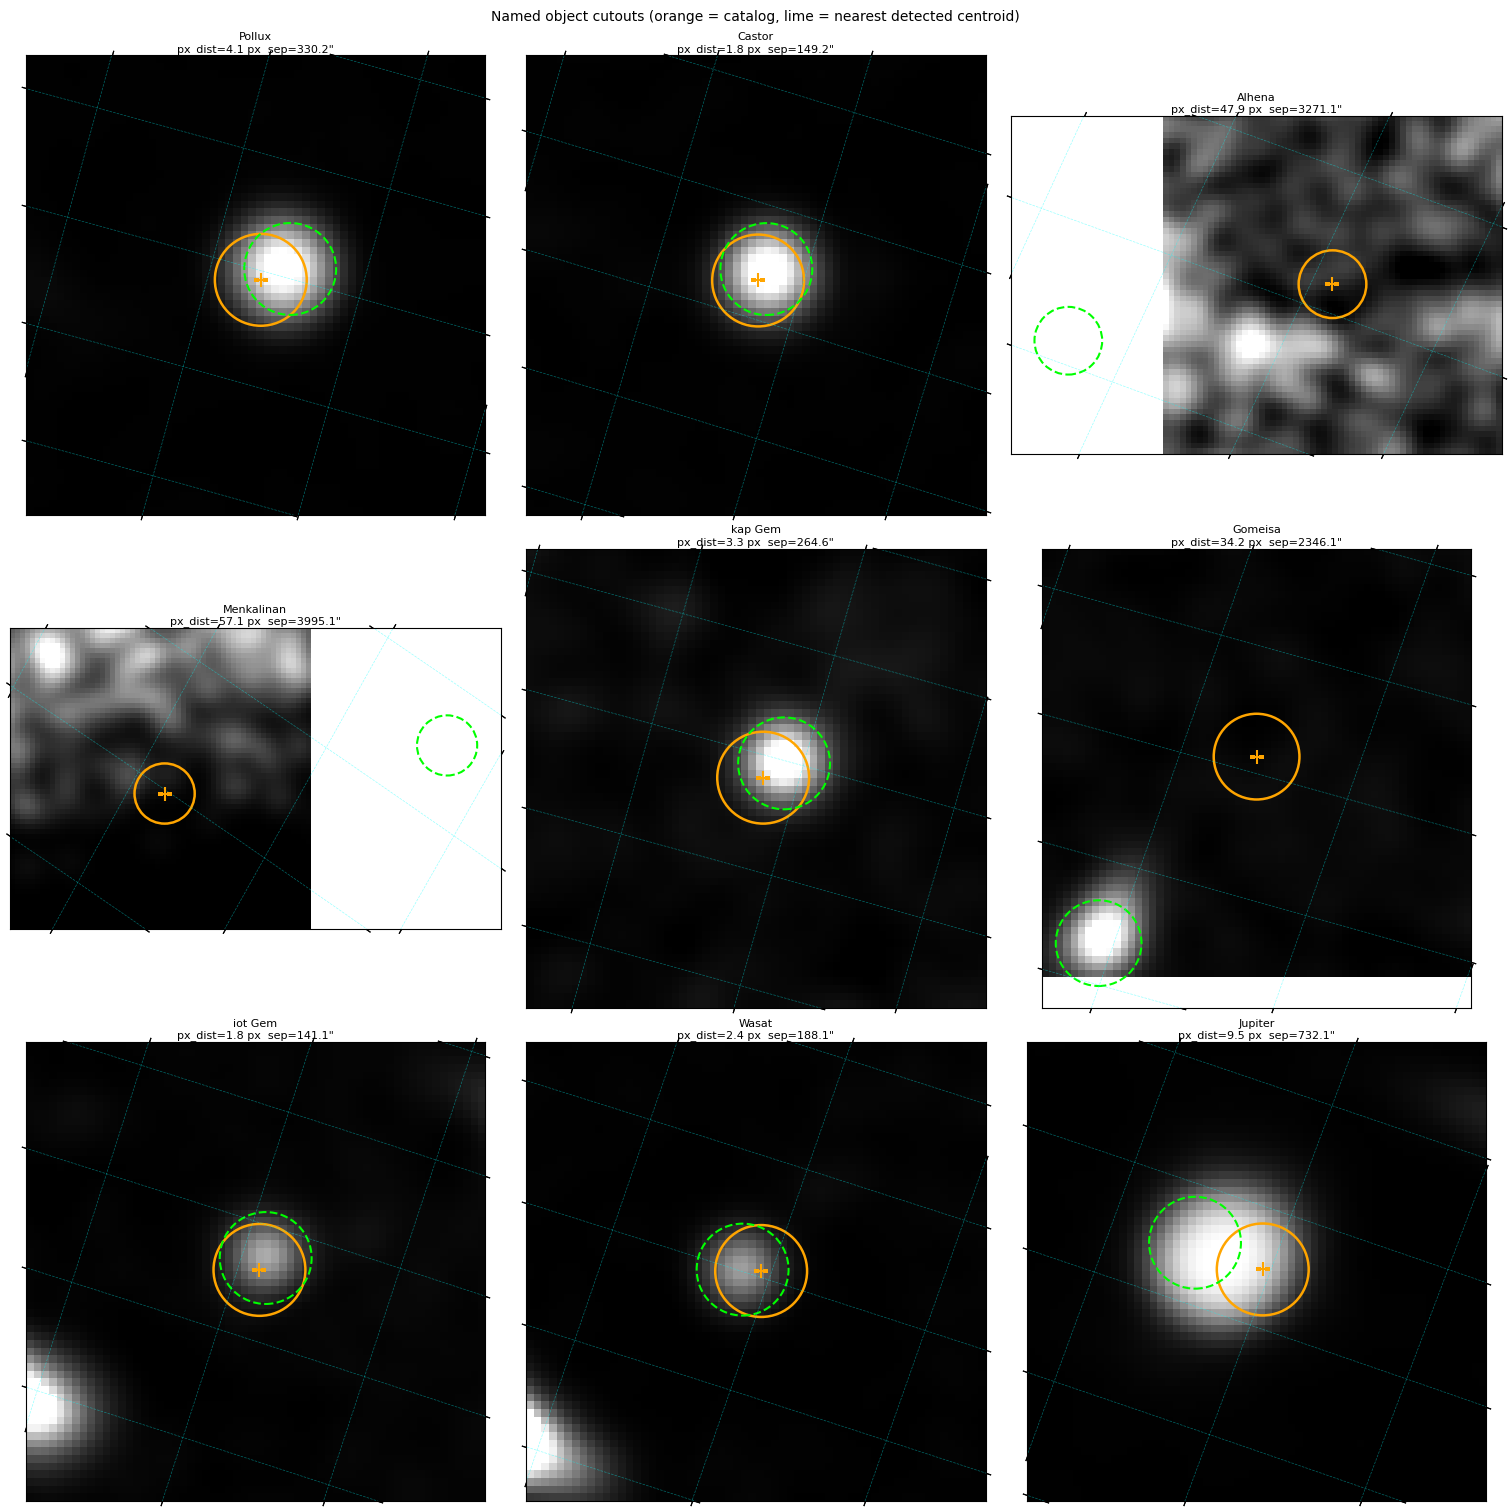

In [8]:
from astropy.nddata import Cutout2D

in_frame = [(name, p) for name, p in predictions.items()
            if 0 <= p['pred_x'] < w and 0 <= p['pred_y'] < h]
if not in_frame:
    print('No named objects in frame.')
else:
    n = len(in_frame)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    fig = plt.figure(figsize=(5*ncols, 5*nrows), constrained_layout=True)
    fig.suptitle('Named object cutouts (orange = catalog, lime = nearest detected centroid)', fontsize=10)

    SIZE = 60
    for idx, (name, p) in enumerate(in_frame):
        ix, iy = int(round(p['pred_x'])), int(round(p['pred_y']))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            cut = Cutout2D(proc, position=(ix, iy), size=SIZE, wcs=wcs, mode='partial', fill_value=0.0)
        fc = cut.data
        c_lo = np.percentile(fc[fc > 0], 1.0) if (fc > 0).any() else 0.0
        c_hi = np.percentile(fc[fc > 0], 99.5) if (fc > 0).any() else 1.0
        c_disp = np.arcsinh(np.clip(fc, c_lo, c_hi))

        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=cut.wcs)
        ax.imshow(c_disp, origin='lower', cmap='gray',
                  vmin=np.arcsinh(c_lo), vmax=np.arcsinh(c_hi))
        ax.coords.grid(True, color='cyan', alpha=0.4, linestyle='--', linewidth=0.5)
        for coord_name in ('ra', 'dec'):
            ax.coords[coord_name].set_ticklabel_visible(False)
            ax.coords[coord_name].set_axislabel('')

        # Catalog-predicted position (orange)
        px_cut = p['pred_x'] - cut.origin_original[0]
        py_cut = p['pred_y'] - cut.origin_original[1]
        ax.add_patch(Circle((px_cut, py_cut), radius=6, edgecolor='orange',
                             facecolor='none', linewidth=1.8))
        ax.plot(px_cut, py_cut, '+', color='orange', markersize=10, markeredgewidth=1.5)

        # Nearest detected centroid (lime)
        if 'near_x' in p and not np.isnan(p['near_x']):
            nx_cut = p['near_x'] - cut.origin_original[0]
            ny_cut = p['near_y'] - cut.origin_original[1]
            ax.add_patch(Circle((nx_cut, ny_cut), radius=6, edgecolor='lime',
                                 facecolor='none', linewidth=1.5, linestyle='--'))

        sep = p.get('sep_arcsec', float('nan'))
        nd  = p.get('px_dist',    float('nan'))
        ax.set_title(f"{name}\npx_dist={nd:.1f} px  sep={sep:.1f}\"",
                     fontsize=8, pad=3)

    plt.savefig(OUT_DIR / 'wcs03_cutouts.png', dpi=150, bbox_inches='tight')
    plt.show()

## Interpretation

**Good outcome:** Every in-frame named object has a detected centroid within 1–2 px (≈ 1–2 × FWHM). The orange WCS-prediction ring sits cleanly on the bright blob.

**Bad / needs attention:**
- A star has no nearby centroid → it was masked by `_diffraction_mask`, or is outside the submitted source list (too faint or too close to image edge).
- Systematic offset in one direction for all stars → global WCS shift; possibly the SIP correction is applied but the reference pixel (CRPIX) is slightly off.
- Jupiter offset ≫ other stars → ephemeris location and/or observer coordinates were incorrect; adjust `MANUAL_TIME` and the observer lat/lon if DATE-OBS was missing.
- Previous SIMBAD coordinate-nearest queries returned obscure entries because the actual star is much brighter than typical catalog neighbors at the same coordinates; querying by name (done here) avoids this entirely.